# Ejercicio 1

## 1. Entorno 

Vamos a empezar cargando todas las librerías necesarias.

In [3]:
import numpy as np
import pandas as pd
import re
import collections
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

Vamos ahora a cargar el CSV y realizamos una inspección inicial para que cualquier decisión de preprocesamiento posterior, sobre qué columnas usar, cómo tratar los nulos, etc... Debe estar justificada en lo que el dato nos muestra, no en suposiciones.

In [4]:
df = pd.read_csv('news_dataset.csv')
print(f'Filas: {len(df):,}   Columnas: {df.shape[1]}')
display(df.head())

Filas: 120,000   Columnas: 3


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Vemos si el dataset tiene valores nulos por columna y la distribución de Class Index.

In [5]:
df.info()
print('Valores nulos: ')
print(df.isnull().sum())

print('Distribución de clases: ')
print(df['Class Index'].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB
Valores nulos: 
Class Index    0
Title          0
Description    0
dtype: int64
Distribución de clases: 
Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


Podemos ver que el dataset no tiene valores nulos, no tiene desbalanceo de clases, es decir, todas las clases tienen el mismo número de noticias, lo que es muy bueno para Ski-gram porque significa que el modelo aprenderá contextos de todas las categorías con la misma intensidad, sin sesgarse hacia ninguna en particular.

Como el dataset codifica la clase como un entero. Añadimos una columna con el nombre de cada categoría para que después sea más fácil la interpretación de todas las visualizaciones.

In [6]:
CLASS_NAMES = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Sci/Tech'
}

df['category'] = df['Class Index'].map(CLASS_NAMES)

NUM_CLASSES = df['Class Index'].nunique()
print(f'Categorías: {list(df["category"].unique())}')
print(df[['Class Index', 'category']].value_counts().sort_index())

Categorías: ['Business', 'Sci/Tech', 'Sports', 'World']
Class Index  category
1            World       30000
2            Sports      30000
3            Business    30000
4            Sci/Tech    30000
Name: count, dtype: int64


Tenemos que medir ahora la longitud en palabras de Title y Description por separado. Esto responde a una pregunta concreta y es si aportan las dos columnas información suficiente para justificar su combinación, o una de ellas es redundante o demasiado corta. Si Title tuviera solo 2–3 palabras de media, su contribución a los pares Skip-Gram sería mínima. Si Description fuera extremadamente larga, podría dominar el vocabulario aprendido.

In [7]:
df['len_title'] = df['Title'].fillna('').apply(lambda x: len(x.split()))
df['len_desc']  = df['Description'].fillna('').apply(lambda x: len(x.split()))

print('Longitud de títulos y descripciones:')
print(df[['len_title', 'len_desc']].describe().round(1))

Longitud de títulos y descripciones:
       len_title  len_desc
count   120000.0  120000.0
mean         6.8      31.1
std          2.1       9.8
min          1.0       1.0
25%          5.0      25.0
50%          7.0      30.0
75%          8.0      36.0
max         19.0     173.0


Vamos a visualizar si la longitud de los textos varía según la categoría. Esto es relevante porque en Skip-Gram los documentos más largos generan más pares de co-ocurrencia y por tanto tienen más influencia en el aprendizaje. Si una categoría tuviera textos más cortos, sus palabras características estarían menos representadas en los pares de entrenamiento, lo que podría degradar la calidad de sus embeddings.

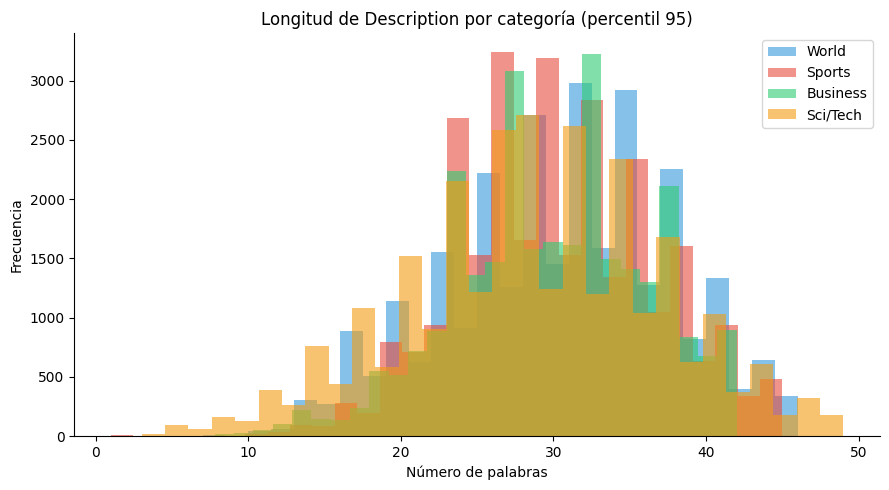

In [8]:
colores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
conteos = df['category'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))

for cat, color in zip(CLASS_NAMES.values(), colores):
    sub = df[df['category'] == cat]['len_desc']
    # Recortamos al percentil 95 para no distorsionar el eje X
    sub_clip = sub[sub <= sub.quantile(0.95)]
    ax.hist(sub_clip, bins=30, alpha=0.6, label=cat, color=color, edgecolor='none')

ax.set_title('Longitud de Description por categoría (percentil 95)', fontsize=12)
ax.set_xlabel('Número de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Antes de aplicar cualquier transformación, vamos a ver qué palabras dominan el corpus en su estado crudo. Tenemos dos objetivos con esto: por un lado, verificar que el texto contiene ruido, que justifica la limpieza, y por otro lado, servir de punto de comparación con la distribución post-limpieza para demostrar el efecto de las transformaciones.

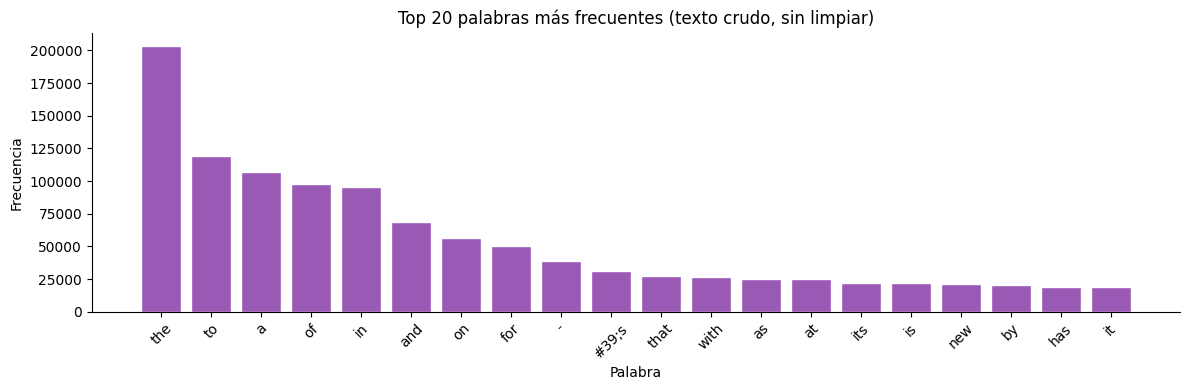

In [9]:
todos_raw = (df['Title'].fillna('') + ' ' + df['Description'].fillna(''))
freq_raw  = collections.Counter(
    w.lower() for doc in todos_raw for w in doc.split()
)

palabras_top, conteos_top = zip(*freq_raw.most_common(20))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(palabras_top, conteos_top, color='#9b59b6', edgecolor='white')
ax.set_title('Top 20 palabras más frecuentes (texto crudo, sin limpiar)', fontsize=12)
ax.set_xlabel('Palabra')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Limpieza del texto

Vamos a aplicar la normalización antes de tokenizar. Cada paso tiene una justificación concreta:
- Minúsculas: sin esta normalización, "News", "news" y "NEWS" serían tres entradas distintas en el vocabulario, triplicando algunas frecuencias y fragmentando el contexto semántico.
- Entidades y etiquetas HTML: los CSV procedentes de scraping web suelen contener residuos como &amp; o <br> que no aportan significado y contaminarían el vocabulario.
- Solo letras a-z: los números y la puntuación no establecen relaciones semánticas entre palabras. Conservarlos aumentaría el vocabulario con tokens sin valor.
- Combinar Title + Description: el título resume el tema central de la noticia y la descripción lo desarrolla. Al final usar ambas columnas maximiza el número de pares de co-ocurrencia disponibles para Skip-Gram.

In [10]:
def limpiar_texto(texto):
    texto = texto.lower() # a minúsculas
    texto = re.sub(r'&[a-z]+;', ' ', texto) # entidades HTML
    texto = re.sub(r'<[^>]+>', ' ', texto) # etiquetas HTML
    texto = re.sub(r'[^a-z\s]', ' ', texto) # solo letras
    texto = re.sub(r'\s+', ' ', texto).strip() # espacios múltiples
    return texto

def tokenizar(texto):
    return texto.split() # dividir el texto limpio en palabras

#combinamos Title + Description
df['texto_completo'] = (
    df['Title'].fillna('') + ' ' + df['Description'].fillna('')
)

textos_limpios = [limpiar_texto(t) for t in df['texto_completo']]
tokens_corpus  = [tokenizar(t)     for t in textos_limpios]

#verificamos que se haya limpiado y tokenizado bien
print('ORIGINAL:')
print(df['texto_completo'].iloc[0])
print('LIMPIO:')
print(textos_limpios[0])
print('TOKENS (primeros 15):')
print(tokens_corpus[0][:15])

ORIGINAL:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
LIMPIO:
wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra cynics are seeing green again
TOKENS (primeros 15):
['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's']


### Construcción del vocabulario

El vocabulario es el diccionario palabra → ID entero que el modelo utiliza internamente, el modelo de deep learning no entiende de palabras, solo números, vamos a aplicar un filtro MIN_FREQ = 5 por dos razones: 
- Las palabras con muy pocas apariciones no tienen suficiente contexto co-ocurrente para que Skip-Gram aprenda un embedding significativo
- Reducir el vocabulario disminuye la memoria requerida y acelera el entrenamiento. Los tokens especiales <PAD> (ID=0) y <UNK> (ID=1) se reservan respectivamente para el relleno de secuencias y para representar palabras fuera del vocabulario en inferencia.

In [11]:
#filtro mínido de frecuencia
MIN_FREQ = 5

#contamos la frecuencia de cada palabra
freq = collections.Counter(
    token for doc in tokens_corpus for token in doc
)

print(f'Palabras únicas (sin filtrar): {len(freq):,}')
print(f'Palabras con freq >= 5: {sum(1 for f in freq.values() if f >= MIN_FREQ):,}')

word2idx = {'<PAD>': 0, '<UNK>': 1}
for palabra, conteo in freq.most_common():
    if conteo >= MIN_FREQ:
        word2idx[palabra] = len(word2idx)

#creamos el diccionario inverso
idx2word   = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Tamaño final del vocabulario: {VOCAB_SIZE:,}')
print('Palabras más frecuentes tras limpieza:')
for palabra, conteo in freq.most_common(20):
    if palabra in word2idx:
        print(f'  {palabra:<15} freq={conteo:>6}  ID={word2idx[palabra]}')

Palabras únicas (sin filtrar): 61,811
Palabras con freq >= 5: 26,898
Tamaño final del vocabulario: 26,900
Palabras más frecuentes tras limpieza:
  the             freq=205473  ID=2
  to              freq=120735  ID=3
  a               freq=113606  ID=4
  of              freq= 98650  ID=5
  in              freq= 96439  ID=6
  and             freq= 69671  ID=7
  s               freq= 62457  ID=8
  on              freq= 57661  ID=9
  for             freq= 50675  ID=10
  that            freq= 28168  ID=11
  with            freq= 26809  ID=12
  as              freq= 25378  ID=13
  at              freq= 25068  ID=14
  its             freq= 22123  ID=15
  is              freq= 22099  ID=16
  new             freq= 21425  ID=17
  by              freq= 20931  ID=18
  it              freq= 20543  ID=19
  said            freq= 20267  ID=20
  reuters         freq= 19340  ID=21


Para comprobar si hemos realizado bien la preparación del corpus representamos la distribución de frecuencias en escala lineal y log-log. La escala log-log nos da bastante información porque si los puntos forman aproximadamente una línea recta, el corpus sigue la Ley de Zipf, que dice que unas pocas palabras concentran la inmensa mayoría de las apariciones, mientras que miles de palabras aparecen una o dos veces.

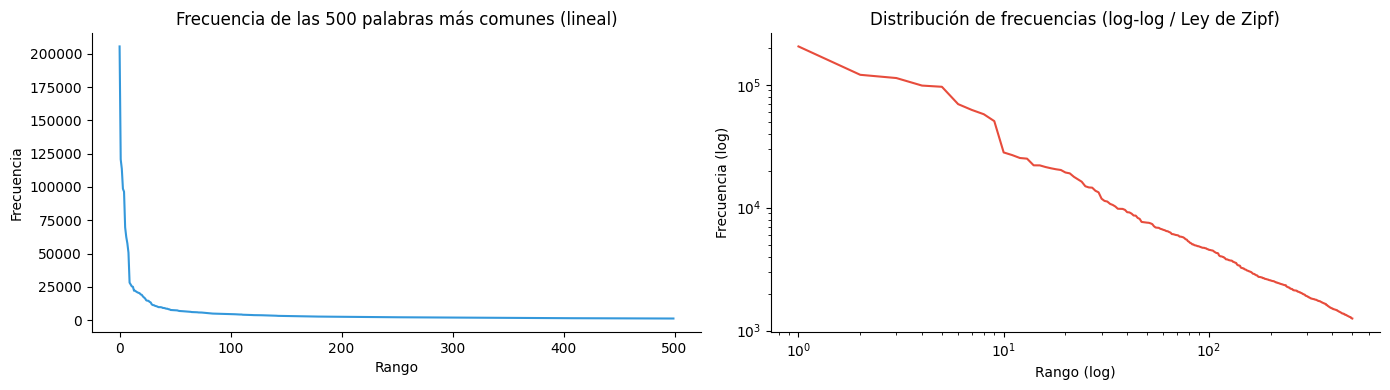

In [12]:
freqs_sorted = sorted(freq.values(), reverse=True)
top_n = min(500, len(freqs_sorted))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_sorted[:top_n], color='#3498db', linewidth=1.5)
axes[0].set_title(f'Frecuencia de las {top_n} palabras más comunes (lineal)')
axes[0].set_xlabel('Rango')
axes[0].set_ylabel('Frecuencia')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].loglog(range(1, top_n+1), freqs_sorted[:top_n], color='#e74c3c', linewidth=1.5)
axes[1].set_title('Distribución de frecuencias (log-log / Ley de Zipf)')
axes[1].set_xlabel('Rango (log)')
axes[1].set_ylabel('Frecuencia (log)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Vamos a analizar las gráficas
- Gráfica lineal: la caída tan pronunciada que hay al principio indica que unas pocas palabras (las stopwords) tienen frecuencias altísimas, mientras que la gran mayoría del vocabulario tiene frecuencias muy bajas, que es precisamente lo que esperabamos.
- Gráfica log-log: la caída de la línea es aproximadamente recta con pendiente negativa, lo cual confirma que el corpus sigue la Ley de Zipf. Esto nos confirma que la elección de MIN_FREQ=5 es buena, las palabras en el extremo derecho de la curva o las más raras, tienen frecuencias tan bajas que no generarían embeddings fiables.

### Concersión texto a IDs

Vamos a convertir cada documento de tokens a IDs enteros usando el vocabulario construido. También vamos a medir la cobertura del vocabulario, es decir el porcentaje de tokens del corpus que tienen un ID asignado (que no sea <UNK>), para que si tenemos una cobertura inferior al 90% nos diría que MIN_FREQ es demasiado alto y estamos perdiendo demasiada información, una cobertura del 95% o más confirma que el filtrado fue conservador y apropiado.

In [13]:
#función para convertir tokens a IDs usando el vocabulario, las q tienen frecuencia < 5 se mapean a <UNK>
def texto_a_ids(tokens_doc, vocabulario):
    UNK_ID = vocabulario.get('<UNK>', 1)
    return [vocabulario.get(token, UNK_ID) for token in tokens_doc]

secuencias = [texto_a_ids(doc, word2idx) for doc in tokens_corpus]
#reindexamos etiquetas de 1-4 a 0-3 (base 0 requerida por Keras)
etiquetas = (df['Class Index'].values - 1).tolist()
total_tokens = sum(len(s) for s in secuencias)
unk_tokens   = sum(s.count(1) for s in secuencias)
print(f'Total tokens en el corpus: {total_tokens:,}')
print(f'Tokens <UNK>: {unk_tokens:,} ({100*unk_tokens/total_tokens:.1f}%)')
print(f'Cobertura del vocabulario: {100*(1 - unk_tokens/total_tokens):.1f}%')

Total tokens en el corpus: 4,575,058
Tokens <UNK>: 60,980 (1.3%)
Cobertura del vocabulario: 98.7%


## Implementación

### Generación de Pares

Como en Skip-Gram el objetivo es aprender a predecir las palabras del contexto a partir de una palabra central, vamos a construir los pares recorriendo cada documento con una ventana deslizante. El tamaño de la ventana define cuántas palabras a izquierda y derecha de la palabra central se consideran contexto, por ejemplo, una ventana de 2 captura relaciones sintácticas más inmediatas, mientras que ventanas de 3 y 4 capturan relaciones semánticas más amplias.

In [14]:
def generar_pares_skipgram(secuencias, window_size):
    pares = []
    for secuencia in secuencias:
        for i, palabra_central in enumerate(secuencia):
            if palabra_central == 0:
                continue
            inicio = max(0, i - window_size)
            fin    = min(len(secuencia), i + window_size + 1)
            for j in range(inicio, fin):
                if j != i and secuencia[j] != 0:
                    pares.append((palabra_central, secuencia[j]))
    return np.array(pares)

pares_w2 = generar_pares_skipgram(secuencias, window_size=2)
print(f'Ventana 2 → {len(pares_w2):,} pares')
pares_w3 = generar_pares_skipgram(secuencias, window_size=3)
print(f'Ventana 3 → {len(pares_w3):,} pares')
pares_w4 = generar_pares_skipgram(secuencias, window_size=4)
print(f'Ventana 4 → {len(pares_w4):,} pares')

Ventana 2 → 17,580,232 pares
Ventana 3 → 26,010,348 pares
Ventana 4 → 34,200,464 pares


### Negative Samplig

Como los pares generados son todos ejemplos positivos, pares de palabras que realmente co-ocurren en el corpus, si entrenamos el modelo solo con ejemplos positivos no funciona porque aprendería a predecir siempre "sí co-ocurren" sin discriminar. El negative sampling resuelve esto añadiendo pares negativos, combinaciones de palabras que no aparecen juntas en el corpus generadas aleatoriamente, entonces por cada par positivo generamos 1 par negativo, con esto mantenemos el dataset balanceado.

In [15]:
def añadir_negative_sampling(pares_positivos, vocab_size):
    n = len(pares_positivos)
    #para pares negativos, ponemos misma palabra central, contexto aleatorio
    cent_neg = pares_positivos[:, 0]  #reutilizamos las palabras centrales
    ctx_neg  = np.random.randint(2, vocab_size, size=n)  #IDs aleatorios (>=2 para evitar <PAD> y <UNK>)
    pares_negativos = np.stack([cent_neg, ctx_neg], axis=1)
    
    #combinamos positivos y negativos
    X = np.concatenate([pares_positivos, pares_negativos], axis=0)
    y = np.concatenate([np.ones(n), np.zeros(n)], axis=0)
    
    #mezclamos para que el modelo no aprenda el orden
    indices = np.random.permutation(len(X))
    return X[indices], y[indices]


X_w2, y_w2 = añadir_negative_sampling(pares_w2, VOCAB_SIZE)
print(f'Ventana 2 → {len(X_w2):,} pares totales ({len(pares_w2):,} pos + {len(pares_w2):,} neg)')
X_w3, y_w3 = añadir_negative_sampling(pares_w3, VOCAB_SIZE)
print(f'Ventana 3 → {len(X_w3):,} pares totales ({len(pares_w3):,} pos + {len(pares_w3):,} neg)')
X_w4, y_w4 = añadir_negative_sampling(pares_w4, VOCAB_SIZE)
print(f'Ventana 4 → {len(X_w4):,} pares totales ({len(pares_w4):,} pos + {len(pares_w4):,} neg)')

Ventana 2 → 35,160,464 pares totales (17,580,232 pos + 17,580,232 neg)
Ventana 3 → 52,020,696 pares totales (26,010,348 pos + 26,010,348 neg)
Ventana 4 → 68,400,928 pares totales (34,200,464 pos + 34,200,464 neg)


### Modelo de Skip-Gram

Skip-Gram lo implementamos como una red neuronal con dos capas de embedding: 1 para la palabra central y otra para la palabra de contexto. 
Cada capa aprende una representación vectorial densa de dimensión emb_dim para cada palabra del vocabulario. 
El producto escalar entre ambos vectores mide su similitud, por ejemplo, si dos palabras co-ocurren frecuentemente, sus vectores aprenderán a apuntar en la misma dirección. 
La función es sigmoide, que convierte ese producto en una probabilidad entre 0 y 1, que interpretamos como probabilidad de que ese par sea real. Usamos binary crossentropy como función de pérdida porque el problema es una clasificación binaria y Adam para minimizar la función de pérdida.

In [16]:
def construir_skipgram(vocab_size, emb_dim):
    #entradas: un ID de palabra central y un ID de palabra de contexto
    input_central  = Input(shape=(1,), name='central')
    input_contexto = Input(shape=(1,), name='contexto')
    
    #capa de embedding compartida para palabras centrales
    embedding = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name='embedding')
    
    #obtenemos vectores para central y contexto
    vec_central  = embedding(input_central)   #(batch, 1, emb_dim)
    vec_contexto = embedding(input_contexto)  #(batch, 1, emb_dim)
    
    #producto escalar: mide similitud entre vectores
    dot = layers.Dot(axes=2, name='dot_product')([vec_central, vec_contexto])
    dot = layers.Flatten()(dot)  # shape: (batch, 1)
    
    # Sigmoid: convierte similitud en probabilidad
    output = layers.Dense(1, activation='sigmoid', name='output')(dot)
    
    model = Model(inputs=[input_central, input_contexto], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# modelo de prueba para verificar la arquitectura
modelo_prueba = construir_skipgram(VOCAB_SIZE, emb_dim=312)
modelo_prueba.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ central             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contexto            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 312)    │  8,392,800 │ central[0][0],    │
│ (Embedding)         │                   │            │ contexto[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1, 1)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_product[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          2 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,392,802 (32.02 MB)

 Trainable params: 8,392,802 (32.02 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento de modelo

In [17]:
PESOS_DIR = 'pesos_modelos'
os.makedirs(PESOS_DIR, exist_ok=True)

EPOCAS     = 10
BATCH_SIZE = 4096

configuraciones = [ 
    (312, 2, X_w2, y_w2, 'dim312_w2'),
    (312, 3, X_w3, y_w3, 'dim312_w3'),
    (312, 4, X_w4, y_w4, 'dim312_w4'),
    (752, 2, X_w2, y_w2, 'dim752_w2'),
    #(752, 3, X_w3, y_w3, 'dim752_w3'),
    (752, 4, X_w4, y_w4, 'dim752_w4')
]

modelos = {}
historiales = {}

for emb_dim, window, X, y, nombre in configuraciones:
    ruta_pesos = f'{PESOS_DIR}/{nombre}.weights.h5'
    ruta_historial = f'{PESOS_DIR}/{nombre}_loss.npy'

    #si ya existen los pesos guardados, los cargamos directamente
    if os.path.exists(ruta_pesos) and os.path.exists(ruta_historial):
        print(f'Cargando pesos desde disco: {nombre}')
        modelo = construir_skipgram(VOCAB_SIZE, emb_dim)
        modelo.load_weights(ruta_pesos)
        historiales[nombre] = np.load(ruta_historial).tolist()

    # Si no existen, entrenamos y guardamos
    else:
        print(f'\n{"="*55}')
        print(f'Entrenando modelo: {nombre}')
        print(f'  Embedding dim : {emb_dim}')
        print(f'  Ventana       : {window}')
        print(f'  Pares totales : {len(X):,}')
        print(f'{"="*55}')

        modelo = construir_skipgram(VOCAB_SIZE, emb_dim)
        hist = modelo.fit(
            [X[:, 0], X[:, 1]],
            y,
            epochs=EPOCAS,
            batch_size=BATCH_SIZE,
            verbose=1
        )

        #gardamos pesos e historial en disco
        modelo.save_weights(ruta_pesos)
        np.save(ruta_historial, np.array(hist.history['loss']))

        historiales[nombre] = hist.history['loss']
        print(f'  Loss final: {hist.history["loss"][-1]:.4f}')
        print(f'  Pesos guardados en: {ruta_pesos}')

    modelos[nombre] = modelo

print('\nTodos los modelos listos.')

Cargando pesos desde disco: dim312_w2
Cargando pesos desde disco: dim312_w3
Cargando pesos desde disco: dim312_w4


c:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 4 PLN\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargando pesos desde disco: dim752_w2
Cargando pesos desde disco: dim752_w4

Todos los modelos listos.


### Representación 

Vamos a mostrar una gráfica de cómo varía la pérdida a lo largo de las épocas para cada red. Representamos los 9 modelos en dos subgráficas separadas por dimensión de embedding, para poder comparar bien el efecto. Si las curvas convergen hacia valores similares independientemente de la ventana, significa que la dimensión del embedding es el factor dominante. Si por el contrario se separan, la ventana tiene un efecto significativo en la velocidad de convergencia.

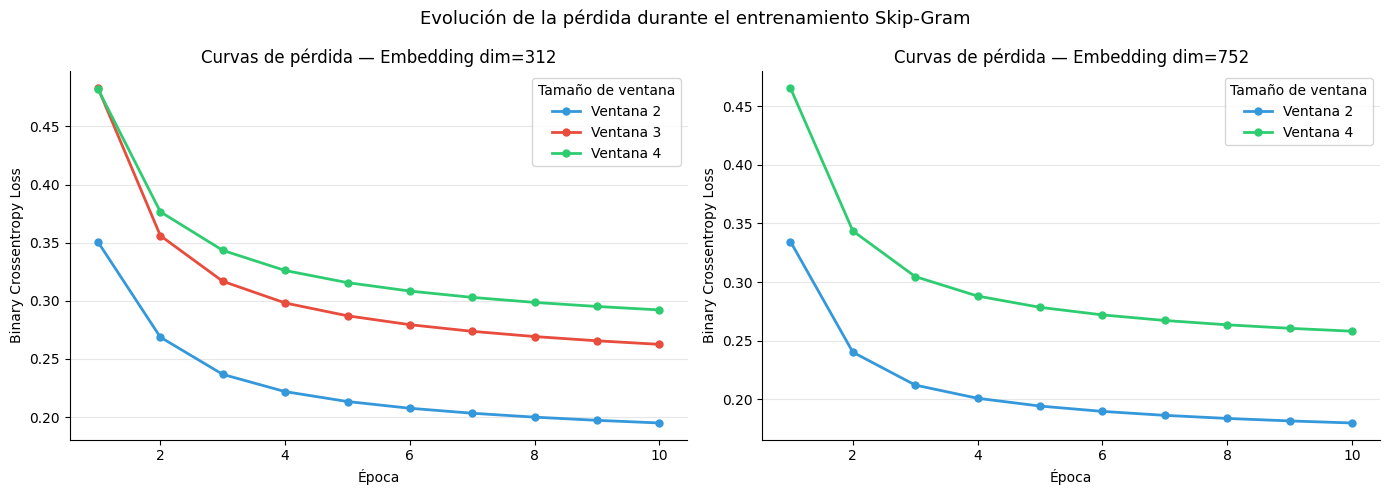

In [ ]:
#extraemos las dimensiones que haya en configuraciones
dims_unicas = list(dict.fromkeys(emb_dim for emb_dim, *_ in configuraciones))
fig, axes = plt.subplots(1, len(dims_unicas), figsize=(7 * len(dims_unicas), 5))

colores_ventana = {2: '#3498db', 3: '#e74c3c', 4: '#2ecc71'}

for ax, emb_dim in zip(axes, dims_unicas):
    for window in [2, 3, 4]:
        nombre = f'dim{emb_dim}_w{window}'
        if nombre not in historiales:
            continue
        loss = historiales[nombre]
        ax.plot(
            range(1, len(loss) + 1),
            loss,
            label=f'Ventana {window}',
            color=colores_ventana[window],
            linewidth=2,
            marker='o',
            markersize=5
        )
    ax.set_title(f'Curvas de pérdida con Embedding dim={emb_dim}', fontsize=12)
    ax.set_xlabel('Época')
    ax.set_ylabel('Binary Crossentropy Loss')
    ax.legend(title='Tamaño de ventana')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Evolución de la pérdida durante el entrenamiento Skip-Gram', fontsize=13)
plt.tight_layout()
plt.show()

Una vez entrenados los modelos y representados, vamos a coger la matriz de embeddings de cada uno. Esta matriz tiene forma: vocab_size, emb_dim, donde cada fila es el vector aprendido para una palabra del vocabulario. La guardamos en un diccionario por nombre de modelo para poder usarla en el ejercicio 2, que es el objetivo de este, usar trasnsfer learning de los mododelos entrenados en el ejericio 1.


In [20]:
EMBEDDINGS_DIR = 'embeddings'
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

embeddings = {}

for emb_dim, window, _, _, nombre in configuraciones:
    if nombre not in modelos:
        continue
    
    #cogemos la matriz de embeddings
    matriz = modelos[nombre].get_layer('embedding').get_weights()[0]
    embeddings[nombre] = matriz
    #guardamos para el ejercicio2
    ruta = f'{EMBEDDINGS_DIR}/{nombre}.npy'
    np.save(ruta, matriz)